<a href="https://colab.research.google.com/github/jujutupaki/Traffic-Congestion-Prediction-using-XGBoost-RF-and-LSTM/blob/main/Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# **Traffic Dataset Cleaning**

## Data Collection
Loading and merging raw traffic Excel files from Google Drive into a single combined CSV dataset.

In [ ]:
# @title Link Dataset from G Drive
'''
# 2. Define the folder paths
jan_path = '/content/drive/MyDrive/Thesis/01 - JANUARY'
feb_path = '/content/drive/MyDrive/Thesis/02 - FEBRUARY'
mar_path = '/content/drive/MyDrive/Thesis/03 - MARCH'
apr_path = '/content/drive/MyDrive/Thesis/04 - APRIL'
may_path = '/content/drive/MyDrive/Thesis/05 - MAY'
june_path = '/content/drive/MyDrive/Thesis/06 - JUNE'
july_path = '/content/drive/MyDrive/Thesis/07 - JULY'
aug_path = '/content/drive/MyDrive/Thesis/08 - AUGUST'
sept_path = '/content/drive/MyDrive/Thesis/09 - SEPTEMBER'
oct_path = '/content/drive/MyDrive/Thesis/10 - OCTOBER'
nov_path = '/content/drive/MyDrive/Thesis/11 - NOVEMBER'
dec_path = '/content/drive/MyDrive/Thesis/12 - DECEMBER'

# Dictionary to specify 0 skip for specific files
# For files not in this dictionary, 5 rows will be skipped by default.
specific_files_to_skip_rows = {
    'LPR 17 - O Shape Overpass - September 13 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 14 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 15 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 16 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 17 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 18 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 19 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 20 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 21 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 22 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 23 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 25 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 26 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 27 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 28 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 29 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - September 30 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - October 01 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - October 02 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - October 03 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - October 04 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - October 05 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - October 06 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - October 07 2025.xlsx': 0,
    'LPR 17 - O Shape Overpass - October 08 2025.xlsx': 0
}

# 3. Search for .xlsx files
jan_files = glob.glob(os.path.join(jan_path, "*.xlsx"))
feb_files = glob.glob(os.path.join(feb_path, "*.xlsx"))
mar_files = glob.glob(os.path.join(mar_path, "*.xlsx"))
apr_files = glob.glob(os.path.join(apr_path, "*.xlsx"))
may_files = glob.glob(os.path.join(may_path, "*.xlsx"))
june_files = glob.glob(os.path.join(june_path, "*.xlsx"))
july_files = glob.glob(os.path.join(july_path, "*.xlsx"))
aug_files = glob.glob(os.path.join(aug_path, "*.xlsx"))
sept_files = glob.glob(os.path.join(sept_path, "*.xlsx"))
oct_files = glob.glob(os.path.join(oct_path, "*.xlsx"))
nov_files = glob.glob(os.path.join(nov_path, "*.xlsx"))
dec_files = glob.glob(os.path.join(dec_path, "*.xlsx"))

all_files = jan_files + feb_files + mar_files + apr_files + may_files + june_files + july_files + aug_files + sept_files + oct_files + nov_files + dec_files

all_data = []

print(f"Found {len(all_files)} Excel files. Starting merge...")

for f in all_files:
    file_basename = os.path.basename(f)

    # Determine skiprows: 0 for specified files, 5 for others
    rows_to_skip = specific_files_to_skip_rows.get(file_basename, 5)

    try:
        # Use the determined skiprows value
        df = pd.read_excel(f, skiprows=rows_to_skip)

        # Add a column to track which file the data came from
        df['Source_File'] = file_basename

        all_data.append(df)
        print(f"Successfully read: {file_basename} (skipped {rows_to_skip} rows)")

    except Exception as e:
        print(f"Error reading {f}: {e}")

# 4. Combine and save as CSV
if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)

    # Save the final result as a CSV
    output_path = '/content/drive/MyDrive/Thesis/Traffic Data/Combined_Traffic_Data_Jan_Dec_2025.csv'
    combined_df.to_csv(output_path, index=False)

    print("-" * 30)
    print(f"DONE! Merged {len(all_data)} files.")
    print(f"Total rows in CSV: {len(combined_df)}")
    print(f"File saved to: {output_path}")
else:
    print("No Excel files were found or processed. Check your folder paths or skip settings.")'''


'\n# 2. Define the folder paths\njan_path = \'/content/drive/MyDrive/Thesis/01 - JANUARY\'\nfeb_path = \'/content/drive/MyDrive/Thesis/02 - FEBRUARY\'\nmar_path = \'/content/drive/MyDrive/Thesis/03 - MARCH\'\napr_path = \'/content/drive/MyDrive/Thesis/04 - APRIL\'\nmay_path = \'/content/drive/MyDrive/Thesis/05 - MAY\'\njune_path = \'/content/drive/MyDrive/Thesis/06 - JUNE\'\njuly_path = \'/content/drive/MyDrive/Thesis/07 - JULY\'\naug_path = \'/content/drive/MyDrive/Thesis/08 - AUGUST\'\nsept_path = \'/content/drive/MyDrive/Thesis/09 - SEPTEMBER\'\noct_path = \'/content/drive/MyDrive/Thesis/10 - OCTOBER\'\nnov_path = \'/content/drive/MyDrive/Thesis/11 - NOVEMBER\'\ndec_path = \'/content/drive/MyDrive/Thesis/12 - DECEMBER\'\n\n# Dictionary to specify 0 skip for specific files\n# For files not in this dictionary, 5 rows will be skipped by default.\nspecific_files_to_skip_rows = {\n    \'LPR 17 - O Shape Overpass - September 13 2025.xlsx\': 0,\n    \'LPR 17 - O Shape Overpass - September 

## Initial Inspection
Loading the combined dataset and performing cheking of datetime parsing, date range filtering, and chronological sorting.

In [ ]:
# Step 5. Load Combined CSV File
df = pd.read_csv('/content/drive/MyDrive/Thesis/Traffic Data/Combined_Traffic_Data_Jan_Dec_2025.csv')

# Step 6. Verify Time Column Format
df['Time'].dtype

# Step 7. Convert Time Column to Datetime Format
df['Time'] = pd.to_datetime(df['Time'], format='mixed')

# Step 8. Filter Data Within Target Date Range
filtered_df = df[
    (df['Time'] >= '2025-01-01 00:00:00') &
    (df['Time'] <= '2025-12-7 23:59:59')
]

# Step 9. Sort Records Chronologically by Datetime
filtered_df = filtered_df.sort_values(by='Time')

# Preview
filtered_df.head()

/tmp/ipykernel_42941/1844965358.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Thesis/Traffic Data/Combined_Traffic_Data_Jan_Dec_2025.csv')


,License Plate No.,Time,Camera,Vehicle List,Vehicle Owner,Phone,Country/Region,Vehicle Type,Brand,Vehicle Color,Driving Direction,Vehicle Speed,Thumbnail,Date,Source_File
7114,Unknown,2025-01-01 00:00:10,LPR 17 - O Shaped Overpass,NaN,NaN,NaN,Not supported.,Two-Wheeler,Others,Others,Backward,0km/h,NaN,2025-01-01,LPR 17 - O Shaped Overpass - January 01 2025.xlsx
7113,Unknown,2025-01-01 00:00:45,LPR 17 - O Shaped Overpass,NaN,NaN,NaN,Not supported.,Two-Wheeler,Others,Others,Forward,0km/h,NaN,2025-01-01,LPR 17 - O Shaped Overpass - January 01 2025.xlsx
7112,Unknown,2025-01-01 00:02:30,LPR 17 - O Shaped Overpass,NaN,NaN,NaN,Not supported.,Two-Wheeler,Others,Others,Backward,0km/h,NaN,2025-01-01,LPR 17 - O Shaped Overpass - January 01 2025.xlsx
7111,QA155W,2025-01-01 00:02:41,LPR 17 - O Shaped Overpass,NaN,NaN,NaN,Malaysia,SUV/MPV,JMC,Gray,Forward,0km/h,NaN,2025-01-01,LPR 17 - O Shaped Overpass - January 01 2025.xlsx
7110,Unknown,2025-01-01 00:04:17,LPR 17 - O Shaped Overpass,NaN,NaN,NaN,Not supported.,Two-Wheeler,Others,Others,Backward,0km/h,NaN,2025-01-01,LPR 17 - O Shaped Overpass - January 01 2025.xlsx


## Data Cleaning
Identifying and handling missing values, removing irrelevant columns, anonymizing license plates, and encoding categorical fields.

In [ ]:
# Step 10. Check for Missing Values Per Column
missing_values = filtered_df.isnull().sum()
missing_values

,0
License Plate No.,1
Time,0
Camera,0
Vehicle List,3454127
Vehicle Owner,3454141
Phone,3454784
Country/Region,0
Vehicle Type,0
Brand,0
Vehicle Color,0


In [ ]:
# Step 11. Drop Irrelevant Columns
filtered_df.drop(['Camera', 'Vehicle List', 'Vehicle Owner', 'Phone', 'Country/Region', 'Vehicle Type', 'Brand', 'Vehicle Color', 'Vehicle Speed', 'Thumbnail', 'Source_File', 'Date'], axis=1, inplace=True, errors='ignore')

# Step 12. Assign Unique Vehicle ID per Record
filtered_df['Vehicle_ID'] = 'VEH_' + np.arange(1, len(filtered_df) + 1).astype(str)

# Step 13. Remove License Plate Number Column
filtered_df.drop(['License Plate No.'], axis=1, inplace=True, errors='ignore')

# Preview
filtered_df.head()

,Time,Driving Direction,Vehicle_ID
7114,2025-01-01 00:00:10,Backward,VEH_1
7113,2025-01-01 00:00:45,Forward,VEH_2
7112,2025-01-01 00:02:30,Backward,VEH_3
7111,2025-01-01 00:02:41,Forward,VEH_4
7110,2025-01-01 00:04:17,Backward,VEH_5


## Feature Engineering
Aggregating raw vehicle records into structured 10-minute interval counts per driving direction, and inspecting traffic distribution.

In [ ]:
# Step 14. Encode Driving Direction as Binary (0=Backward, 1=Forward)
if filtered_df['Driving Direction'].dtype == 'object':
    filtered_df['Driving Direction'] = filtered_df['Driving Direction'].map({'Backward': 0, 'Forward': 1})

# Step 15. Create 10-Minute Interval Timestamp Column
filtered_df['10_Minutes_Interval'] = filtered_df['Time'].dt.floor('10min')

# Step 16. Aggregate Vehicle Count per Direction per 10-Minute Interval
interval_df = (
    filtered_df
    .groupby(['10_Minutes_Interval', 'Driving Direction'])['Vehicle_ID']
    .count()
    .unstack(fill_value=0)   # ensures both 0 and 1 appear
    .stack()
    .reset_index(name='Vehicle_Count')
)

# Step 17. Drop Columns No Longer Needed After Aggregation
filtered_df = filtered_df.drop(columns=['Vehicle_ID', 'Time'])

# Step 18. Print Highest and Lowest Traffic Intervals per Driving Direction
for direction, label in [(1, 'Forward'), (0, 'Backward')]:
    subset = interval_df[interval_df['Driving Direction'] == direction]

    if subset.empty:
        print(f"=== {label} ===")
        print(f"No traffic data found for {label} direction.\n")
        continue

    max_row = subset.loc[subset['Vehicle_Count'].idxmax()]
    min_row = subset.loc[subset['Vehicle_Count'].idxmin()]

    print(f"=== {label} ===")
    print(f"Highest traffic: {max_row['Vehicle_Count']} cars at {max_row['10_Minutes_Interval']}")
    print(f"Lowest  traffic: {min_row['Vehicle_Count']} cars at {min_row['10_Minutes_Interval']}\n")

# View final processed dataframe
print(interval_df.head())

=== Forward ===
Highest traffic: 166 cars at 2025-01-04 22:20:00
Lowest  traffic: 0 cars at 2025-01-30 15:30:00

=== Backward ===
Highest traffic: 71 cars at 2025-04-27 06:00:00
Lowest  traffic: 0 cars at 2025-01-04 02:50:00

  10_Minutes_Interval  Driving Direction  Vehicle_Count
0 2025-01-01 00:00:00                  0             11
1 2025-01-01 00:00:00                  1             11
2 2025-01-01 00:10:00                  0              8
3 2025-01-01 00:10:00                  1             79
4 2025-01-01 00:20:00                  0              9


In [ ]:
#Step 19. Count Total Rows in Interval DataFrame
interval_df.shape[0]

90428

## Missing Data Analysis
Detecting missing dates and incomplete 10-minute intervals to assess data gaps before imputation.

In [ ]:
# Extract date from 10_Minutes_Interval column
# Note: 'Time' and 'Vehicle_ID' columns have been dropped in previous steps.
# '10_Minutes_Interval' is now the primary time-related column.

# Ensure '10_Minutes_Interval' is datetime type
# This check is added for robustness, in case the column type changes unexpectedly.
if not pd.api.types.is_datetime64_any_dtype(filtered_df['10_Minutes_Interval']):
    filtered_df['10_Minutes_Interval'] = pd.to_datetime(filtered_df['10_Minutes_Interval'])

filtered_df['Date'] = filtered_df['10_Minutes_Interval'].dt.date

# Get the full expected date range using the min/max of '10_Minutes_Interval'
full_dates = pd.date_range(
    start=filtered_df['10_Minutes_Interval'].min().date(),
    end=filtered_df['10_Minutes_Interval'].max().date()
)

# Get existing dates in the dataset from the newly created 'Date' column
existing_dates = pd.to_datetime(filtered_df['Date'].unique())

# Find missing dates
missing_dates = full_dates.difference(existing_dates)

# Print missing dates
if len(missing_dates) == 0:
    print("No missing dates in the dataset.")
else:
    print("Missing Dates:")
    for d in missing_dates:
        print(d.date())

Missing Dates:
2025-01-20
2025-02-01
2025-02-02
2025-02-03
2025-02-04
2025-02-05
2025-02-06
2025-02-07
2025-02-08
2025-02-28
2025-03-19
2025-04-15
2025-05-25
2025-08-02
2025-08-03
2025-08-14
2025-08-15
2025-08-18
2025-08-19
2025-08-20
2025-08-22
2025-08-23
2025-11-05
2025-11-08
2025-11-10


In [ ]:
import pandas as pd

# Expected 10-minute intervals per day (full day template)
full_day_intervals = pd.date_range("00:00", "23:59", freq="10min").time

missing_summary = {}

for date, group in filtered_df.groupby('Date'):

   # Skip if this is one of your missing full days
   if date in missing_dates:
       continue

   # Get actual intervals present in this day
   actual_intervals = set(group['10_Minutes_Interval'].dt.time.unique())

   # Find missing intervals for this day
   missing_intervals = set(full_day_intervals) - actual_intervals

   if missing_intervals:
       missing_summary[date] = len(missing_intervals)

# Print results
total_missing = sum(missing_summary.values())

print(f"Total missing 10-minute intervals (excluding missing days): {total_missing}\n")

for date, count in missing_summary.items():
   print(f"{date}: {count} missing intervals")

Total missing 10-minute intervals (excluding missing days): 290

2025-01-10: 21 missing intervals
2025-01-30: 4 missing intervals
2025-02-19: 3 missing intervals
2025-02-22: 14 missing intervals
2025-02-23: 13 missing intervals
2025-05-04: 3 missing intervals
2025-05-20: 2 missing intervals
2025-06-10: 21 missing intervals
2025-06-27: 27 missing intervals
2025-06-28: 10 missing intervals
2025-07-01: 19 missing intervals
2025-07-23: 3 missing intervals
2025-07-25: 13 missing intervals
2025-07-28: 11 missing intervals
2025-08-12: 6 missing intervals
2025-09-03: 23 missing intervals
2025-09-06: 4 missing intervals
2025-09-07: 5 missing intervals
2025-09-22: 1 missing intervals
2025-09-23: 6 missing intervals
2025-09-26: 2 missing intervals
2025-10-09: 57 missing intervals
2025-10-10: 2 missing intervals
2025-10-14: 5 missing intervals
2025-11-09: 9 missing intervals
2025-11-11: 6 missing intervals


In [ ]:
expected_directions = [0, 1]
expected_times = pd.date_range("00:00:00", "23:59:00", freq="10min").time

missing_summary = {}

# Add the 'Date' column to interval_df before grouping
interval_df['Date'] = interval_df['10_Minutes_Interval'].dt.date

for date, group in interval_df.groupby('Date'):

    if date in missing_dates:
        continue

    # Build actual pairs (time, direction)
    actual_pairs = set(
        zip(
            group['10_Minutes_Interval'].dt.time,
            group['Driving Direction']
        )
    )

    missing_count = 0

    for t in expected_times:
        for d in expected_directions:
            if (t, d) not in actual_pairs:
                missing_count += 1

    if missing_count > 0:
        missing_summary[date] = missing_count

total_missing = sum(missing_summary.values())

print(f"Total missing direction-level intervals: {total_missing}\n")

for date, count in missing_summary.items():
    print(f"{date}: {count} missing direction-intervals")

Total missing direction-level intervals: 580

2025-01-10: 42 missing direction-intervals
2025-01-30: 8 missing direction-intervals
2025-02-19: 6 missing direction-intervals
2025-02-22: 28 missing direction-intervals
2025-02-23: 26 missing direction-intervals
2025-05-04: 6 missing direction-intervals
2025-05-20: 4 missing direction-intervals
2025-06-10: 42 missing direction-intervals
2025-06-27: 54 missing direction-intervals
2025-06-28: 20 missing direction-intervals
2025-07-01: 38 missing direction-intervals
2025-07-23: 6 missing direction-intervals
2025-07-25: 26 missing direction-intervals
2025-07-28: 22 missing direction-intervals
2025-08-12: 12 missing direction-intervals
2025-09-03: 46 missing direction-intervals
2025-09-06: 8 missing direction-intervals
2025-09-07: 10 missing direction-intervals
2025-09-22: 2 missing direction-intervals
2025-09-23: 12 missing direction-intervals
2025-09-26: 4 missing direction-intervals
2025-10-09: 114 missing direction-intervals
2025-10-10: 4 m

## Imputation & Gap Filling
Constructing weekly and monthly temporal profiles to fill missing intervals using context-aware statistical imputation.

In [ ]:
# Step 20. Extract Temporal Features and Normalize 10-Minute Time Buckets
import pandas as pd
import numpy as np

# Ensure datetime format
interval_df['10_Minutes_Interval'] = pd.to_datetime(interval_df['10_Minutes_Interval'])

# Extract temporal features
interval_df['Date'] = interval_df['10_Minutes_Interval'].dt.date
interval_df['Week'] = interval_df['10_Minutes_Interval'].dt.isocalendar().week
interval_df['Month'] = interval_df['10_Minutes_Interval'].dt.month

# Normalize to consistent 10-minute time buckets
interval_df['TimeOfDay'] = interval_df['10_Minutes_Interval'].dt.floor('10min').dt.time

# Step 21. Build Weekly and Monthly Temporal Profiles for Imputation
# Weekly aggregate (mean and count, high priority)
weekly_agg = (
    interval_df
    .groupby(['Week', 'TimeOfDay', 'Driving Direction'])['Vehicle_Count']
    .agg(Vehicle_Count_Mean='mean', Vehicle_Count_N='count') # Calculate both mean and count
    .reset_index()
)

# Monthly mean profile (fallback)
monthly_mean = (
    interval_df
    .groupby(['Month', 'TimeOfDay', 'Driving Direction'])['Vehicle_Count']
    .mean()
    .reset_index()
)

#Step 22: Hierarchical Imputation of Missing 10-Minute Traffic Intervals
imputed_rows = []

# If a specific (Week, TimeOfDay, Direction) combination has this many or fewer observations,
# we fall back to monthly. A value of 1 means if there's only one observation, use monthly.
MIN_WEEKLY_OBSERVATIONS = 1 # User specified 'only one value', so use 1

for d in missing_dates:

    full_range = pd.date_range(
        start=pd.Timestamp(d),
        end=pd.Timestamp(d) + pd.Timedelta(hours=23, minutes=50),
        freq='10min'
    )

    week = pd.Timestamp(d).isocalendar().week
    month = pd.Timestamp(d).month

    for t in full_range:
        time_of_day = t.time()

        for direction in [0, 1]:

            imputed_value = None # Initialize imputed_value

            # Try Priority 1: Weekly pattern
            weekly_match = weekly_agg[
                (weekly_agg['Week'] == week) &
                (weekly_agg['TimeOfDay'] == time_of_day) &
                (weekly_agg['Driving Direction'] == direction)
            ]

            if not weekly_match.empty and weekly_match['Vehicle_Count_N'].iloc[0] > MIN_WEEKLY_OBSERVATIONS:
                imputed_value = weekly_match['Vehicle_Count_Mean'].iloc[0]

            # If weekly pattern was not used or didn't meet threshold, try Priority 2: Monthly pattern
            if imputed_value is None:
                monthly_match = monthly_mean[
                    (monthly_mean['Month'] == month) &
                    (monthly_mean['TimeOfDay'] == time_of_day) &
                    (monthly_mean['Driving Direction'] == direction)
                ]['Vehicle_Count']

                if not monthly_match.empty:
                    imputed_value = monthly_match.iloc[0]

            # Final fallback, and round to whole number
            value = np.round(imputed_value) if imputed_value is not None else 0

            imputed_rows.append({
                '10_Minutes_Interval': t,
                'Driving Direction': direction,
                'Vehicle_Count': value,
                'Imputed': True
            })

#Step 23: Generation of Complete Missing Interval Time Series
# Convert imputed rows into DataFrame
imputed_df = pd.DataFrame(imputed_rows)

# Mark original data
interval_df['Imputed'] = False

#Step 24: Integration and Consolidation of Observed and Imputed Data
# Combine original and imputed datasets
cleaned_df = pd.concat([interval_df, imputed_df], ignore_index=True)

# Sort chronologically
cleaned_df = cleaned_df.sort_values(['10_Minutes_Interval', 'Driving Direction'])

# Preview result
cleaned_df.head()

,10_Minutes_Interval,Driving Direction,Vehicle_Count,Date,Week,Month,TimeOfDay,Imputed
0,2025-01-01 00:00:00,0,11.0,2025-01-01,1,1.0,00:00:00,False
1,2025-01-01 00:00:00,1,11.0,2025-01-01,1,1.0,00:00:00,False
2,2025-01-01 00:10:00,0,8.0,2025-01-01,1,1.0,00:10:00,False
3,2025-01-01 00:10:00,1,79.0,2025-01-01,1,1.0,00:10:00,False
4,2025-01-01 00:20:00,0,9.0,2025-01-01,1,1.0,00:20:00,False


In [ ]:
cleaned_df.drop(columns=['Date', 'Week', 'Month', 'TimeOfDay', 'Imputed'], inplace=True, errors='ignore')

#Preview
cleaned_df.head()

,10_Minutes_Interval,Driving Direction,Vehicle_Count
0,2025-01-01 00:00:00,0,11.0
1,2025-01-01 00:00:00,1,11.0
2,2025-01-01 00:10:00,0,8.0
3,2025-01-01 00:10:00,1,79.0
4,2025-01-01 00:20:00,0,9.0


## Target Variable Creation
Applying K-Means clustering per driving direction to generate the Simulated Traffic Level label (Low / Moderate / High).

In [ ]:
# Step 25. Apply K-Means Clustering per Direction to Classify Traffic Levels (Low/Moderate/High)
cleaned_df['Simulated Traffic Level'] = pd.NA

for direction in [0, 1]:
    mask = cleaned_df['Driving Direction'] == direction
    subset = cleaned_df.loc[mask, ['Vehicle_Count']]

    # Fit model using Vehicle Count
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    cleaned_df.loc[mask, 'Traffic Cluster'] = kmeans.fit_predict(subset)

    # Get cluster centers
    cluster_centers = kmeans.cluster_centers_.flatten()

    # Sort clusters based on vehicle Count
    sorted_clusters = np.argsort(cluster_centers)

    # Create mapping for labels
    cluster_labels = {
        sorted_clusters[0]: 0,
        sorted_clusters[1]: 1,
        sorted_clusters[2]: 2
        }

    # Apply labels
    cleaned_df.loc[mask, 'Simulated Traffic Level'] = cleaned_df.loc[mask, 'Traffic Cluster'].map(cluster_labels)

# Drop cluster column
cleaned_df.drop(columns=['Traffic Cluster'], inplace=True)

# Preview
cleaned_df.head()

,10_Minutes_Interval,Driving Direction,Vehicle_Count,Simulated Traffic Level
0,2025-01-01 00:00:00,0,11.0,0
1,2025-01-01 00:00:00,1,11.0,0
2,2025-01-01 00:10:00,0,8.0,0
3,2025-01-01 00:10:00,1,79.0,2
4,2025-01-01 00:20:00,0,9.0,0


## Visualization


Visualizing the distribution of the target variable and reviewing weekly traffic congestion trends across directions.

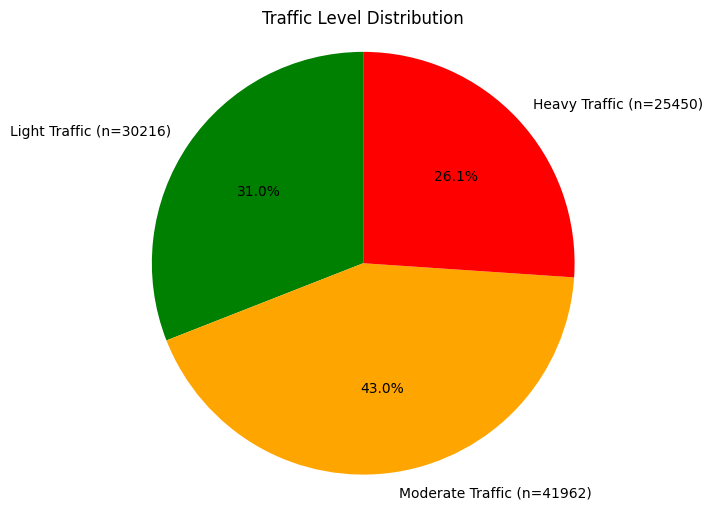

In [ ]:
#Plotting the target variable class distribution
colors = ["green", "orange", "red"]
labels = ["Light Traffic", "Moderate Traffic", "Heavy Traffic"]

counts = cleaned_df['Simulated Traffic Level'].value_counts().sort_index()

plt.figure(figsize=(6, 6))

plt.pie(
    counts,
    labels=[f"{labels[i]} (n={counts[i]})" for i in counts.index],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Traffic Level Distribution")
plt.axis('equal')
plt.show()

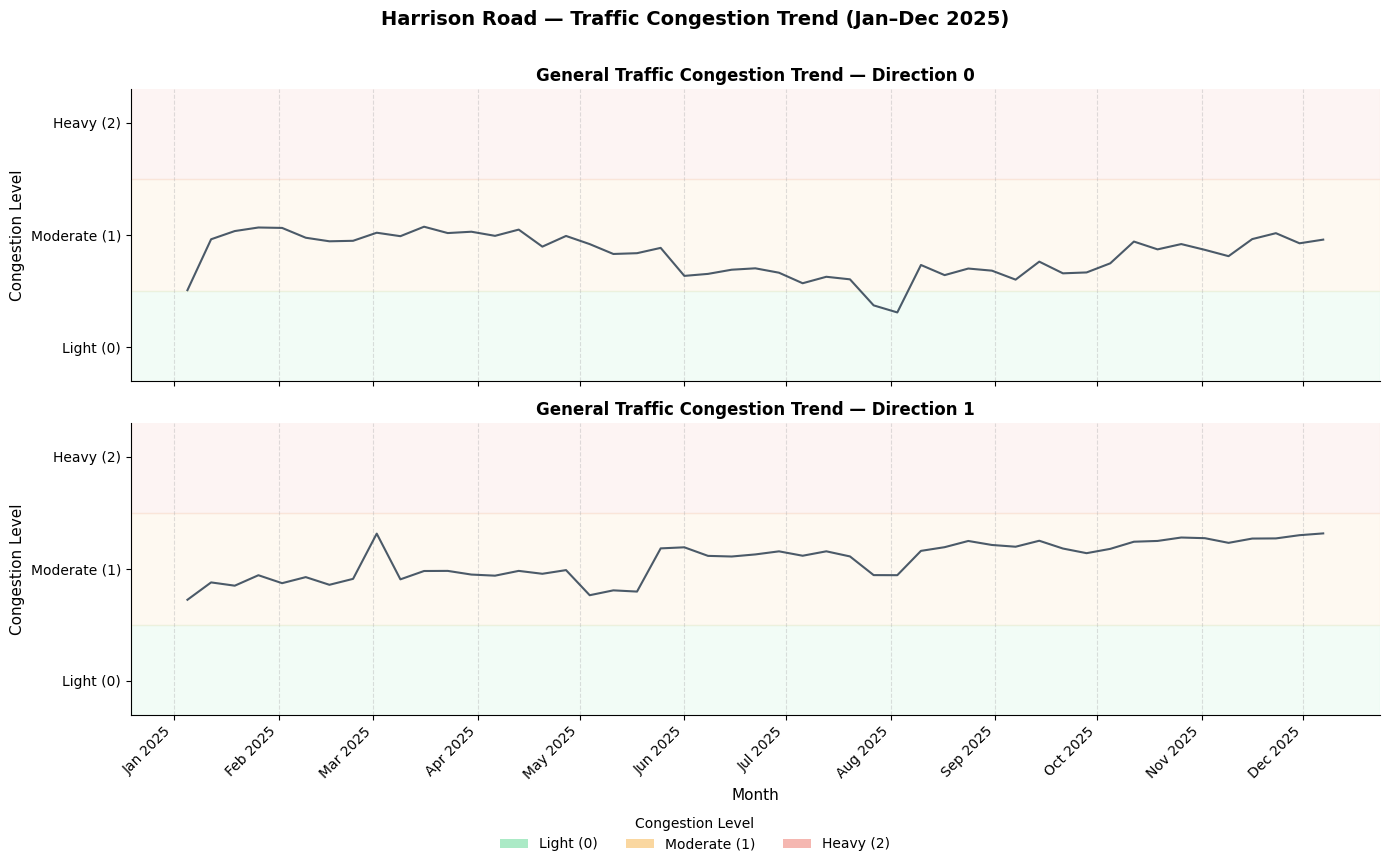

In [ ]:
# @title General Traffic Level Trend using Weekly Average
dir0 = cleaned_df[cleaned_df['Driving Direction'] == 0].copy()
dir1 = cleaned_df[cleaned_df['Driving Direction'] == 1].copy()

dir0_weekly = (dir0.set_index('10_Minutes_Interval')['Simulated Traffic Level']
                   .resample('W').mean())
dir1_weekly = (dir1.set_index('10_Minutes_Interval')['Simulated Traffic Level']
                   .resample('W').mean())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

yticks      = [0, 1, 2]
ylabels     = ['Light (0)', 'Moderate (1)', 'Heavy (2)']
level_color = ['#2ecc71', '#f39c12', '#e74c3c']   # green / orange / red

for ax, data, direction in zip(axes,
                                [dir0_weekly, dir1_weekly],
                                ['Direction 0', 'Direction 1']):

    ax.plot(data.index, data.values,
            color='#2c3e50', linewidth=1.5, alpha=0.85)

    ax.axhspan(-0.5,  0.5, alpha=0.06, color='#2ecc71')   # light
    ax.axhspan( 0.5,  1.5, alpha=0.06, color='#f39c12')   # moderate
    ax.axhspan( 1.5,  2.5, alpha=0.06, color='#e74c3c')   # heavy

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=10)
    ax.set_ylim(-0.3, 2.3)
    ax.set_ylabel('Congestion Level', fontsize=11)
    ax.set_title(f'General Traffic Congestion Trend — {direction}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right', fontsize=10)
axes[1].set_xlabel('Month', fontsize=11)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', alpha=0.4, label='Light (0)'),
                   Patch(facecolor='#f39c12', alpha=0.4, label='Moderate (1)'),
                   Patch(facecolor='#e74c3c', alpha=0.4, label='Heavy (2)')]
fig.legend(handles=legend_elements,
           loc='center', ncol=3,
           bbox_to_anchor=(0.5, -0.02),
           fontsize=10, frameon=False,
           title='Congestion Level', title_fontsize=10)

plt.suptitle('Harrison Road — Traffic Congestion Trend (Jan–Dec 2025)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('traffic_trend_by_direction.png', dpi=150, bbox_inches='tight')
plt.show()

## Export Cleaned Traffic Dataset
Saving the final processed traffic DataFrame as a CSV file to Google Drive.

In [ ]:
output_path = '/content/drive/MyDrive/Thesis/Traffic Data/TRAFFIC DATASET.csv'

cleaned_df.to_csv(output_path, index=False)

print("Processed DataFrame saved successfully.")

Processed DataFrame saved successfully.


# **Weather Dataset Cleaning**

## Data Collection
Loading the raw weather CSV from Google Drive, skipping metadata header rows.

In [ ]:
from google.colab import drive
import pandas as pd

# Step 1. Mount Google Drive
drive.mount('/content/drive')

# Step 2. Define Raw Weather Data File Path
raw_weather_data_path = '/content/drive/MyDrive/Thesis/Raw Weather Data/Weather Data Jan-Dec.csv'

# Step 3. Load Weather CSV, Skipping Metadata Header Rows
df = pd.read_csv(raw_weather_data_path, skiprows=3)

# Step 4. Initial Inspection and Diagnostic Check
print("--- Initial Inspection ---")
print(df.head())
print("\n--- Info ---")
df.info()

print("\n--- Diagnostic Check ---")
total_rows = df.shape[0]
total_cols = df.shape[1]
duplicate_count = df.duplicated().sum()
missing_values = df.isnull().sum()

print(f"Total Rows: {total_rows}")
print(f"Total Columns: {total_cols}")
print(f"Number of duplicate rows found: {duplicate_count}")

print("\n--- Missing Values Per Column ---")
missing_data = missing_values[missing_values > 0]
if not missing_data.empty:
    missing_percentage = (missing_data / total_rows) * 100
    missing_info = pd.DataFrame({
        'Missing Count': missing_data,
        'Missing Percentage': missing_percentage.map('{:.2f}%'.format)
    }).sort_values(by='Missing Count', ascending=False)
    print(missing_info)
else:
    print("No missing values found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Initial Inspection ---
               time  temperature_2m (°C)  relative_humidity_2m (%)  \
0  2025-01-01T00:00                 14.6                        99   
1  2025-01-01T01:00                 14.1                       100   
2  2025-01-01T02:00                 13.8                       100   
3  2025-01-01T03:00                 13.7                       100   
4  2025-01-01T04:00                 13.8                        99   

   dew_point_2m (°C)  apparent_temperature (°C)  precipitation (mm)  \
0               14.4                       15.6                 0.0   
1               14.1                       14.7                 0.0   
2               13.8                       14.2                 0.0   
3               13.6                       14.0                 0.0   
4               13.6                       14.1                 0.0 

## Export Cleaned Weather Dataset
Saving the cleaned weather DataFrame as a CSV file to Google Drive.

In [ ]:
import os

output_path = '/content/drive/MyDrive/Thesis/Raw Weather Data/WEATHER DATASET.csv'

os.makedirs(os.path.dirname(output_path), exist_ok=True)

df.to_csv(output_path, index=False)

print("Processed DataFrame saved successfully.")

Processed DataFrame saved successfully.


# **Joining Traffic and Weather Dataset**

## Load Processed Datasets
Reading the cleaned traffic and weather CSVs and preparing hourly time keys for the merge operation.

In [ ]:
import pandas as pd

# Step 1. Load the processed traffic data
traffic_df = pd.read_csv('/content/drive/MyDrive/Thesis/Traffic Data/TRAFFIC DATASET.csv')

# Step 2. Load the processed weather data
weather_df = pd.read_csv('/content/drive/MyDrive/Thesis/Raw Weather Data/WEATHER DATASET.csv')

# --- Prepare Traffic Data ---
# Ensure '10_Minutes_Interval' is datetime and create an hourly key
traffic_df['10_Minutes_Interval'] = pd.to_datetime(traffic_df['10_Minutes_Interval'])
traffic_df['Hourly_Time'] = traffic_df['10_Minutes_Interval'].dt.floor('h') # Changed 'H' to 'h'

# --- Prepare Weather Data ---
# Ensure 'time' is datetime and rename for merging
weather_df['time'] = pd.to_datetime(weather_df['time'])
weather_df.rename(columns={'time': 'Hourly_Time'}, inplace=True)

## Dataset Merging
Performing a left join on the hourly time key to combine traffic and weather data into a single unified DataFrame.

In [ ]:
# Step 3. Merge (Left Join)
# We join 'traffic_df' with 'weather_df' using 'Hourly_Time' from traffic and 'Hourly_Time' from weather
merged_df = pd.merge(traffic_df, weather_df, left_on='Hourly_Time', right_on='Hourly_Time', how='left')

## Merge Preview
Inspecting the tail of the merged dataset to confirm successful join of traffic and weather records.

In [ ]:
# Display the first few rows of the merged DataFrame
#merged_df.head()
merged_df.tail()

,10_Minutes_Interval,Driving Direction,Vehicle_Count,Simulated Traffic Level,Hourly_Time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),...,soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_gusts_10m (km/h)
97623,2025-12-07 23:30:00,1,55.0,1,2025-12-07 23:00:00,15.8,89,14.0,16.9,0.0,...,0.338,0.397,846.3,100,10,0,100,0.2,1.6,13.3
97624,2025-12-07 23:40:00,0,9.0,0,2025-12-07 23:00:00,15.8,89,14.0,16.9,0.0,...,0.338,0.397,846.3,100,10,0,100,0.2,1.6,13.3
97625,2025-12-07 23:40:00,1,64.0,1,2025-12-07 23:00:00,15.8,89,14.0,16.9,0.0,...,0.338,0.397,846.3,100,10,0,100,0.2,1.6,13.3
97626,2025-12-07 23:50:00,0,18.0,1,2025-12-07 23:00:00,15.8,89,14.0,16.9,0.0,...,0.338,0.397,846.3,100,10,0,100,0.2,1.6,13.3
97627,2025-12-07 23:50:00,1,54.0,1,2025-12-07 23:00:00,15.8,89,14.0,16.9,0.0,...,0.338,0.397,846.3,100,10,0,100,0.2,1.6,13.3


## Cyclical Temporal Encoding
Encoding time-based features (minute, hour, day, week, month) as sine/cosine pairs to preserve cyclical continuity for model input.

In [ ]:
# Step 4. Generate Cyclical Temporal Features from 10-Minute Interval Timestamps

merged_df['10_Minutes_Interval'] = pd.to_datetime(merged_df['10_Minutes_Interval'])

# ── Extract temporal features from 10_Minutes_Interval ───────────────────────
merged_df['10_Minutes_Interval'] = pd.to_datetime(merged_df['10_Minutes_Interval'])

merged_df['Minute']    = merged_df['10_Minutes_Interval'].dt.minute
merged_df['Hour']      = merged_df['10_Minutes_Interval'].dt.hour
merged_df['Day']       = merged_df['10_Minutes_Interval'].dt.day
merged_df['DayOfWeek'] = merged_df['10_Minutes_Interval'].dt.dayofweek
merged_df['Week']      = merged_df['10_Minutes_Interval'].dt.isocalendar().week.astype(int)
merged_df['Month']     = merged_df['10_Minutes_Interval'].dt.month
merged_df['DayOfYear'] = merged_df['10_Minutes_Interval'].dt.dayofyear

# Drop all datetime columns after extraction
merged_df.drop(columns=['Time', 'Hourly_Time','Vehicle_ID'], inplace=True, errors='ignore')
print(merged_df.dtypes)

10_Minutes_Interval                   datetime64[ns]
Driving Direction                              int64
Vehicle_Count                                float64
Simulated Traffic Level                        int64
temperature_2m (°C)                          float64
relative_humidity_2m (%)                       int64
dew_point_2m (°C)                            float64
apparent_temperature (°C)                    float64
precipitation (mm)                           float64
rain (mm)                                    float64
soil_temperature_0_to_7cm (°C)               float64
soil_temperature_7_to_28cm (°C)              float64
soil_temperature_28_to_100cm (°C)            float64
soil_temperature_100_to_255cm (°C)           float64
soil_moisture_0_to_7cm (m³/m³)               float64
soil_moisture_7_to_28cm (m³/m³)              float64
soil_moisture_28_to_100cm (m³/m³)            float64
soil_moisture_100_to_255cm (m³/m³)           float64
surface_pressure (hPa)                       f

## Export Final Combined Dataset
Saving the fully merged and feature-engineered traffic-weather DataFrame as the final CSV for model training.

In [ ]:
import os

# Save the merged DataFrame to a new CSV file
output_combined_path = '/content/drive/MyDrive/Thesis/Dataset/Combined_Traffic_Weather_Data(Removed_Cyclical_Encoding).csv'

# Ensure the directory exists
os.makedirs(os.path.dirname(output_combined_path), exist_ok=True)

merged_df.to_csv(output_combined_path, index=False)
print(f"\nCombined dataset saved to: {output_combined_path}")


Combined dataset saved to: /content/drive/MyDrive/Thesis/Dataset/Combined_Traffic_Weather_Data(Removed_Cyclical_Encoding).csv
